In [ ]:
pip install pillow

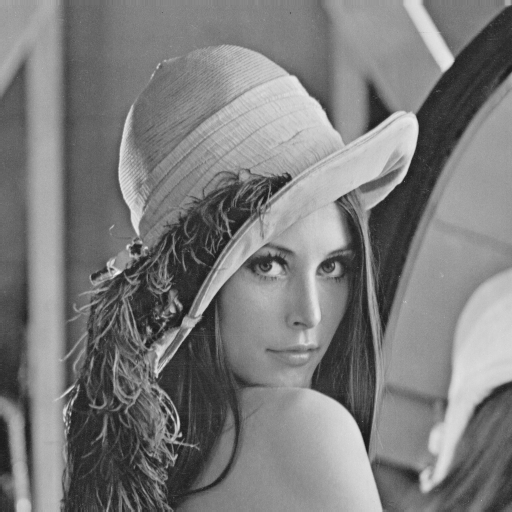

In [ ]:
from PIL import Image

# open image
image_colored = Image.open("/content/lena_gray.gif")

# display image
display(image_colored)

In [ ]:
print("Image Format:", image_colored.format)
print("Image Size:", image_colored.size)
print("Image Mode:", image_colored.mode)

Image Format: GIF
Image Size: (512, 512)
Image Mode: P


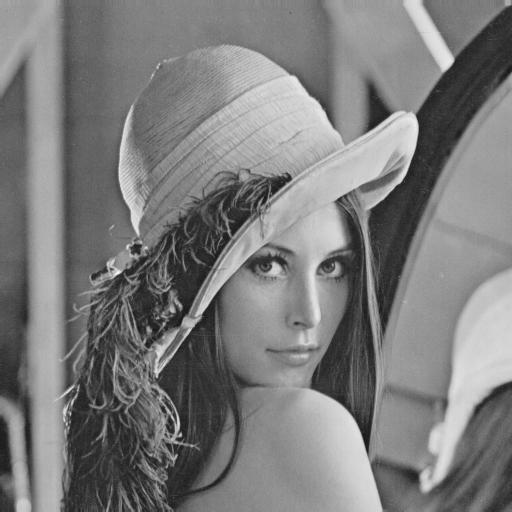

Image shape (Grayscale): (512, 512, 1)
Image size (Grayscale): 262144


In [ ]:
from PIL import Image
from IPython.display import display

# Open image
image_colored = Image.open("/content/lena_gray.gif")

# Convert to grayscale
image_grayed = image_colored.convert("L")

# Display grayscale image
display(image_grayed)

# Get the size (width, height) and channels
width, height = image_grayed.size
channels = len(image_grayed.getbands())
print(f"Image shape (Grayscale): ({height}, {width}, {channels})")

image_size_grayed = width * height * 1
print(f"Image size (Grayscale): {image_size_grayed}")

In [ ]:
import numpy as np

# Convert the Pillow image to a NumPy array
image_array_grayed = np.array(image_grayed)

# Display the shape of the NumPy array (height, width)
print("Shape of the image array:", image_array_grayed.shape)

# Convert the Pillow image to a NumPy array
image_array_grayed = np.array(image_grayed)

# Display the shape of the NumPy array (height, width)
print("Shape of the image array:", image_array_grayed.shape)

Shape of the image array: (512, 512)
Shape of the image array: (512, 512)


100th row shape: (512, 3)


array([[ 87,  87,  87],
       [ 87,  87,  87],
       [ 78,  78,  78],
       ...,
       [163, 163, 163],
       [162, 162, 162],
       [167, 167, 167]], dtype=uint8)

50th column shape: (512, 3)


array([[167, 167, 167],
       [167, 167, 167],
       [167, 167, 167],
       ...,
       [182, 182, 182],
       [178, 178, 178],
       [178, 178, 178]], dtype=uint8)

Pixel at (10,20): [158 158 158]


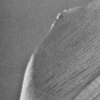

In [ ]:
from PIL import Image
import numpy as np
from IPython.display import display

# Open an image (make sure it's RGB for full example)
image_colored = Image.open("/content/lena_gray.gif").convert("RGB")

# Convert to NumPy array
image_array = np.array(image_colored)

# ---------------------------
# Accessing specific parts
# ---------------------------

# Access 100th row
row_100 = image_array[100, :, :]
print("100th row shape:", row_100.shape)
display(row_100)

# Access 50th column
col_50 = image_array[:, 50, :]
print("50th column shape:", col_50.shape)
display(col_50)

# Access specific pixel (row 10, col 20)
pixel = image_array[10, 20, :]  # RGB values at (10, 20)
print("Pixel at (10,20):", pixel)

# ---------------------------
# Cropping using PIL
# ---------------------------

# Define cropping box: (left, upper, right, lower)
left, upper, right, lower = 100, 50, 200, 150

# Crop the image
cropped_image = image_colored.crop((left, upper, right, lower))

# Display the cropped image
display(cropped_image)

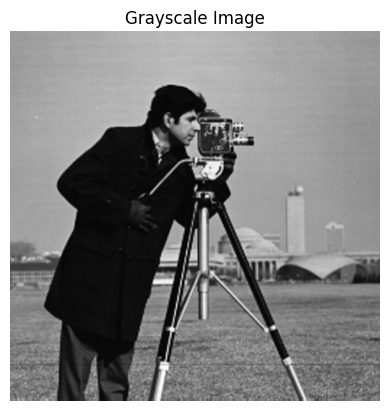

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image and convert to grayscale
image = Image.open("cameraman.png").convert("L")

# Convert to NumPy array
image_array = np.array(image)

# Get image dimensions
height, width = image_array.shape

# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array.reshape(height, width)

# Optional: visualize the image
plt.imshow(image_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [ ]:
# Compute the mean of each column (feature)
mean = np.mean(data, axis=0)

# Subtract mean to center the data
centered_data = data - mean

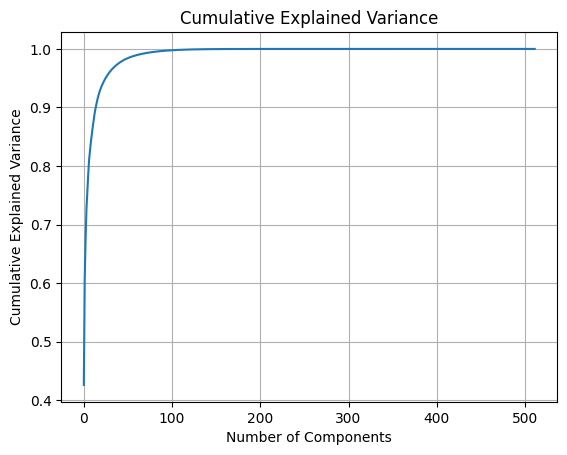

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose 'data' is your n x d matrix of features
# Step 1: Center the data
mean = np.mean(data, axis=0)
centered_data = data - mean

# Step 2: Compute covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Step 4: Sort eigenvalues in descending order
eigenvalues = np.flip(np.sort(eigenvalues))

# Step 5: Compute explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Step 6: Plot cumulative explained variance
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [ ]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [ ]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [ ]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T )+mean

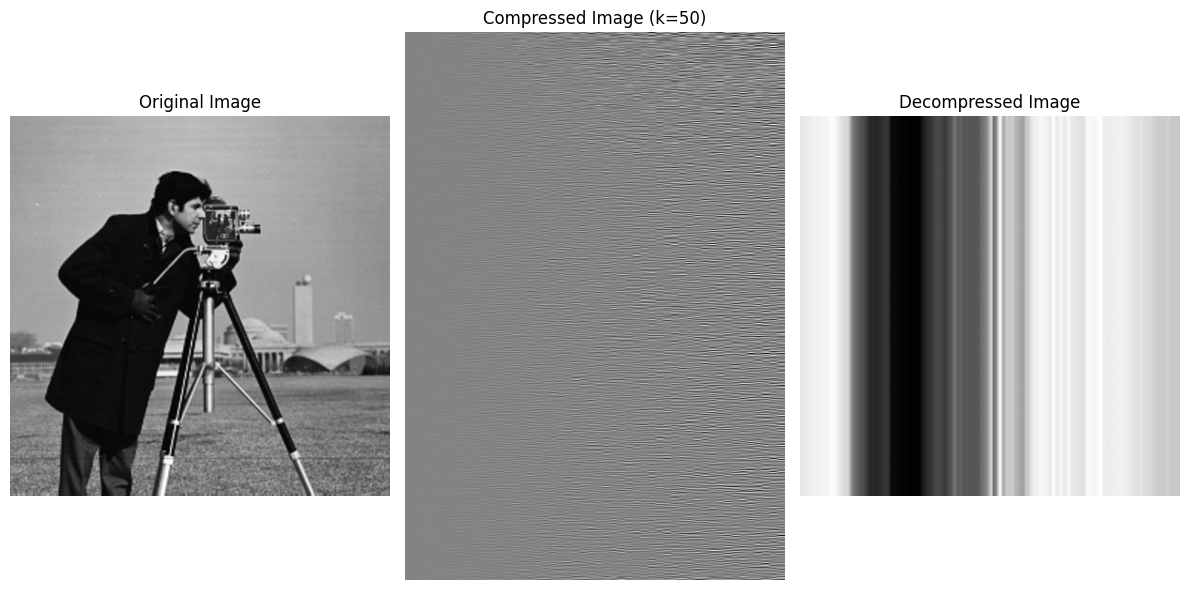

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()